# Результаты

### Базовый процент аномалий: 0.17% (492)

Посчитаем разобранными на занятии методами процент и количество аномалий. (Важно отметить, что стремиться будем к базовому проценту аномалий)
- STD аномалии: **0.15% (433)**. Аномалий определено правильно: **77**
- STD аномалии (трансформация к нормальному распределению): **0.15% (433)**. Аномалий определено правильно: **0**
- IQR аномалии: **0.17% (480)**. Аномалий определено правильно: **15**
- Аномалии по евклидовому расстоянию: **0.17% (492)**. Аномалий определено правильно: **18**
- Аномалии по манхэттенскому расстоянию: **0.17% (492)**. Аномалий определено правильно: **112**
- SVM аномалии: **0.97% (2776)**. Аномалий определено правильно: **148**
- Isolation Forest аномалии: **0.17% (492)**. Аномалий определено правильно: **120**

К моему сожалению DBSCAN использовать не удалось. У моего компьютера недостаточно оперативной памяти. Результаты, которых удалось достичь, далеки от ожидаемых (процент аномали >50).


In [35]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.base import BaseEstimator
from scipy.spatial.distance import cdist
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import umap

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

source_data = pd.read_csv(f"{path}/creditcard.csv")

data = source_data.copy(deep=True).drop(["Class"], axis=1)

scaled_data = pd.DataFrame(
    data=RobustScaler().fit_transform(data),
    columns=data.columns
)

data.info(verbose=False)
print("=" * 100)
print(data.isna().sum())
print("=" * 100)
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Columns: 30 entries, Time to Amount
dtypes: float64(30)
memory usage: 65.2 MB
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [3]:
# Слишком долго считается, 143 минуты на моем пк
#sns.pairplot(source_data, hue="Class")

<Axes: >

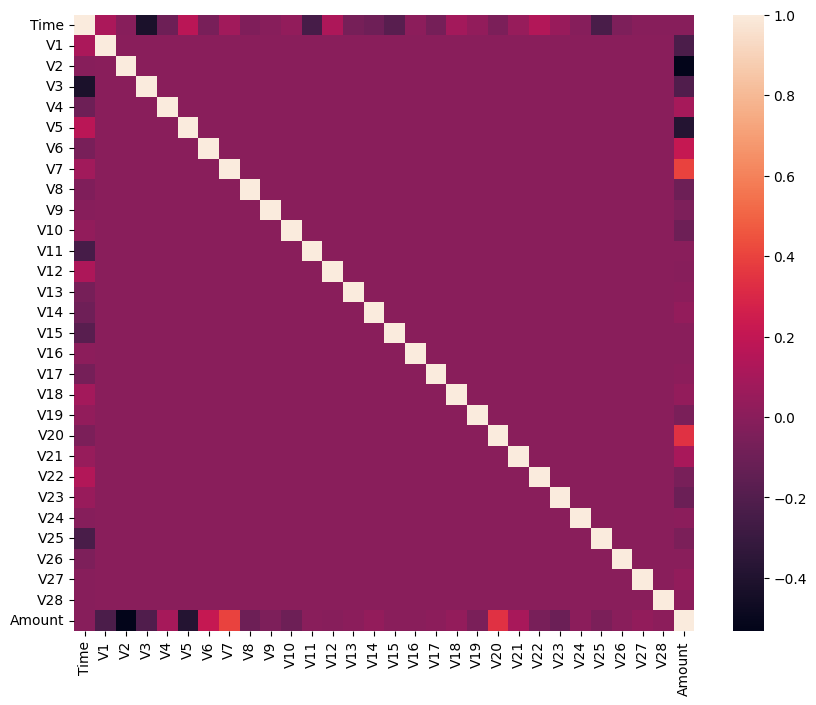

In [4]:
correlation_threshold = .85 # Значение корреляции, которые мы считаем сильным

correlated_columns = dict() # Колонки, которые коррелируют между собой

corr_data = data.corr()

for column in corr_data.columns:
    values_bigger_than_threshold = corr_data[column][corr_data[column] > correlation_threshold]
    correlated_columns[column] = list(values_bigger_than_threshold.index)
    correlated_columns[column].remove(column)
    
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data)

In [ ]:
def show_clusters(X, labels, reducer=None, axis=plt):
    if reducer:
        X_reduced = reducer.fit_transform(X)
        axis.scatter(X_reduced[:,0], X_reduced[:,1], c=labels)
    else:
        _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))
        show_clusters(data, labels, reducer=PCA(n_components=2), axis=ax1)
        ax1.set_title("PCA(2)")
        show_clusters(data, labels, reducer=TSNE(), axis=ax2)
        ax2.set_title("TSNE")
        show_clusters(data, labels, reducer=umap.UMAP(), axis=ax3)
        ax3.set_title("UMAP")

In [36]:
anomalies = source_data['Class'].value_counts()[1]
values = source_data['Class'].count()
anomalies_percent = anomalies / values * 100
print(f"Процент аномалий в датасете: {anomalies} / {values} = {anomalies_percent}%")

# show_clusters(data, source_data['Class'])

Процент аномалий в датасете: 492 / 284807 = 0.1727485630620034%


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>],
       [<Axes: title={'center': 'V5'}>, <Axes: title={'center': 'V6'}>,
        <Axes: title={'center': 'V7'}>, <Axes: title={'center': 'V8'}>,
        <Axes: title={'center': 'V9'}>],
       [<Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>,
        <Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>],
       [<Axes: title={'center': 'V15'}>, <Axes: title={'center': 'V16'}>,
        <Axes: title={'center': 'V17'}>, <Axes: title={'center': 'V18'}>,
        <Axes: title={'center': 'V19'}>],
       [<Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>,
        <Axes: title={'center': 'V24'}>],
       [<Axes: title={'center': 'V25'}>, <Axes: title={'ce

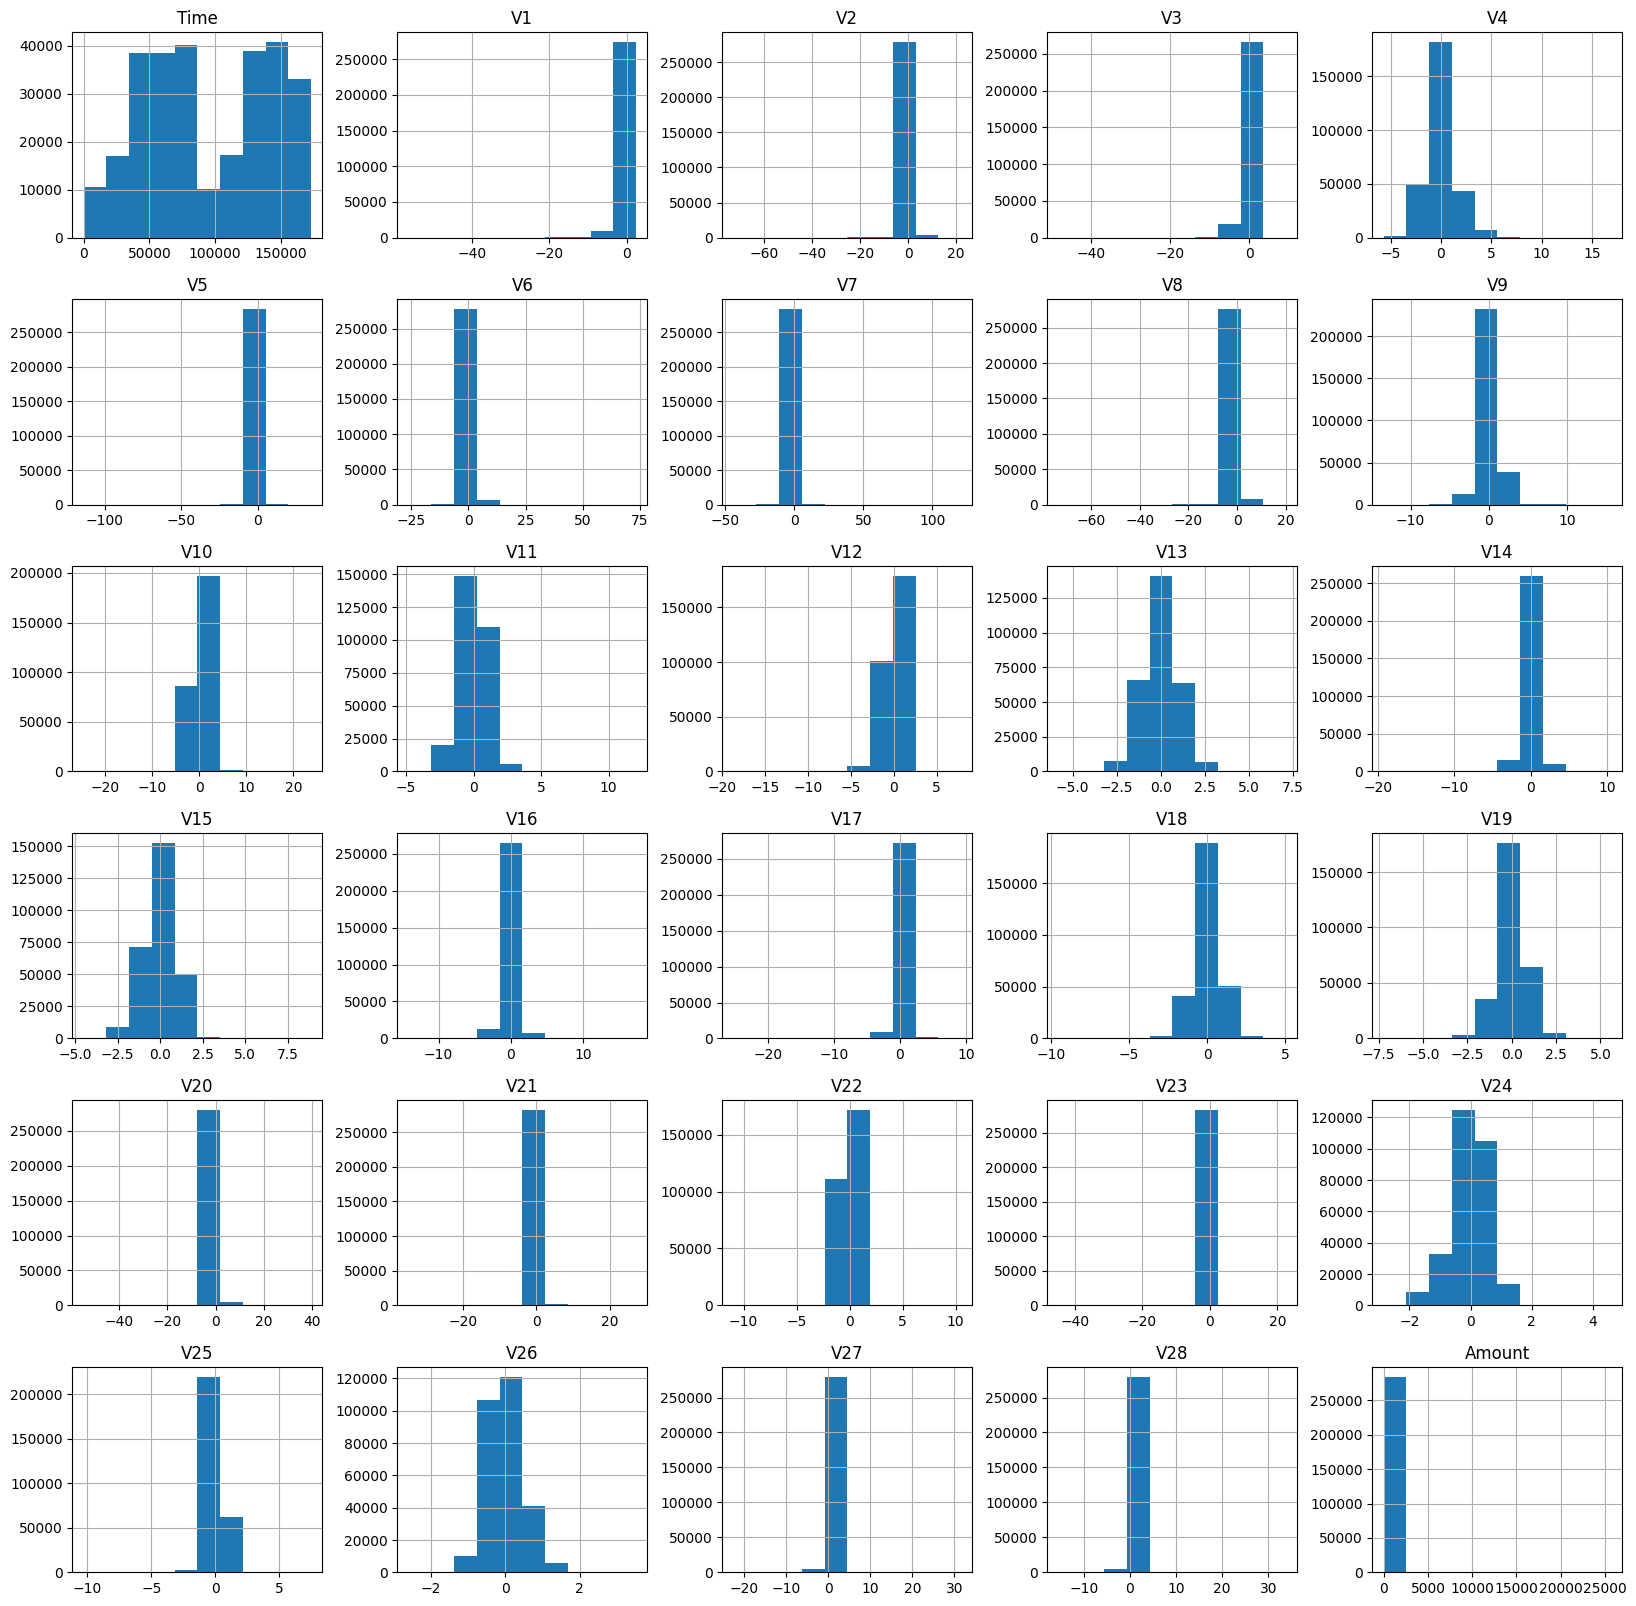

In [7]:
data.hist(figsize=(20, 20))

In [8]:
def outlier_std(data, col, threshold=3):
    mean = data[col].mean()
    std = data[col].std()
    up_bound = mean + threshold * std
    low_bound = mean - threshold * std
    anomalies = pd.concat([data[col]>up_bound, data[col]<low_bound], axis=1).any(axis = 1)
    return anomalies, up_bound, low_bound

In [9]:
def get_column_outliers(data, function, columns=None, threshold=3):
    if columns:
        columns_to_check = columns
    else:
        columns_to_check = data.columns

    outliers = pd.Series(data=[False]*len(data), index=data.index, name='is_outlier')
    comparison_table = {}
    for column in columns_to_check:
        anomalies, upper_bound, lower_bound = function(data, column, threshold=threshold)
        comparison_table[column] = [upper_bound, lower_bound, sum(anomalies), 100*sum(anomalies)/len(anomalies)]
        outliers[anomalies[anomalies].index] = True

    comparison_table = pd.DataFrame(comparison_table).T
    comparison_table.columns=['upper_bound', 'lower_bound', 'anomalies_count', 'anomalies_percentage']
    comparison_table = comparison_table.sort_values(by='anomalies_percentage', ascending=False)

    return comparison_table, outliers

def anomalies_report(outliers):
    outliers_sum = sum(outliers)
    outliers_percent = 100*sum(outliers)/len(outliers)
    print(f"Total number of outliers: {outliers_sum}\nPercentage of outliers: {outliers_percent}")
    return outliers_sum, outliers_percent
    
def find_anomalies_threashold(data, function):
    min_percent = float("inf")
    for thr in range(1, 100):
        comparison_table, outliers = get_column_outliers(data, function, threshold=thr)
        std_anomalies_percent = 100 * sum(outliers) / len(outliers)
        if std_anomalies_percent < min_percent:
            min_percent = std_anomalies_percent
        if min_percent <= anomalies_percent:
            break
    return comparison_table, outliers

In [10]:
comparison_table, std_outliers = find_anomalies_threashold(data, outlier_std)
std_outliers_count, std_outliers_percent = anomalies_report(std_outliers)
comparison_table

Total number of outliers: 433
Percentage of outliers: 0.1520327800931859


,upper_bound,lower_bound,anomalies_count,anomalies_percentage
V23,11.864746,-11.864746,100.0,0.035111
V21,13.955956,-13.955956,81.0,0.028440
V28,6.271582,-6.271582,78.0,0.027387
V20,14.647575,-14.647575,75.0,0.026334
Amount,4840.631695,-4663.932456,62.0,0.021769
V8,22.692705,-22.692705,61.0,0.021418
V17,16.137404,-16.137404,58.0,0.020365
V2,31.374863,-31.374863,38.0,0.013342
V7,23.504778,-23.504778,36.0,0.012640
V27,7.669017,-7.669017,31.0,0.010885


In [11]:
transformed_data = pd.DataFrame(
    data=QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(data),
    columns=data.columns
)
comparison_table, std_t_outliers = find_anomalies_threashold(transformed_data, outlier_std)
std_t_outliers_count, std_t_outliers_percent = anomalies_report(std_outliers)
comparison_table

Total number of outliers: 433
Percentage of outliers: 0.1520327800931859


,upper_bound,lower_bound,anomalies_count,anomalies_percentage
Time,6.047325,-6.032430,0.0,0.0
V1,6.024093,-5.992265,0.0,0.0
V2,5.961119,-5.973303,0.0,0.0
V3,6.009158,-6.006778,0.0,0.0
V4,6.063025,-6.064809,0.0,0.0
V5,5.952225,-5.958424,0.0,0.0
V6,6.028501,-5.991921,0.0,0.0
V7,5.975529,-5.974965,0.0,0.0
V8,5.967775,-5.962974,0.0,0.0
V9,6.029332,-6.030249,0.0,0.0


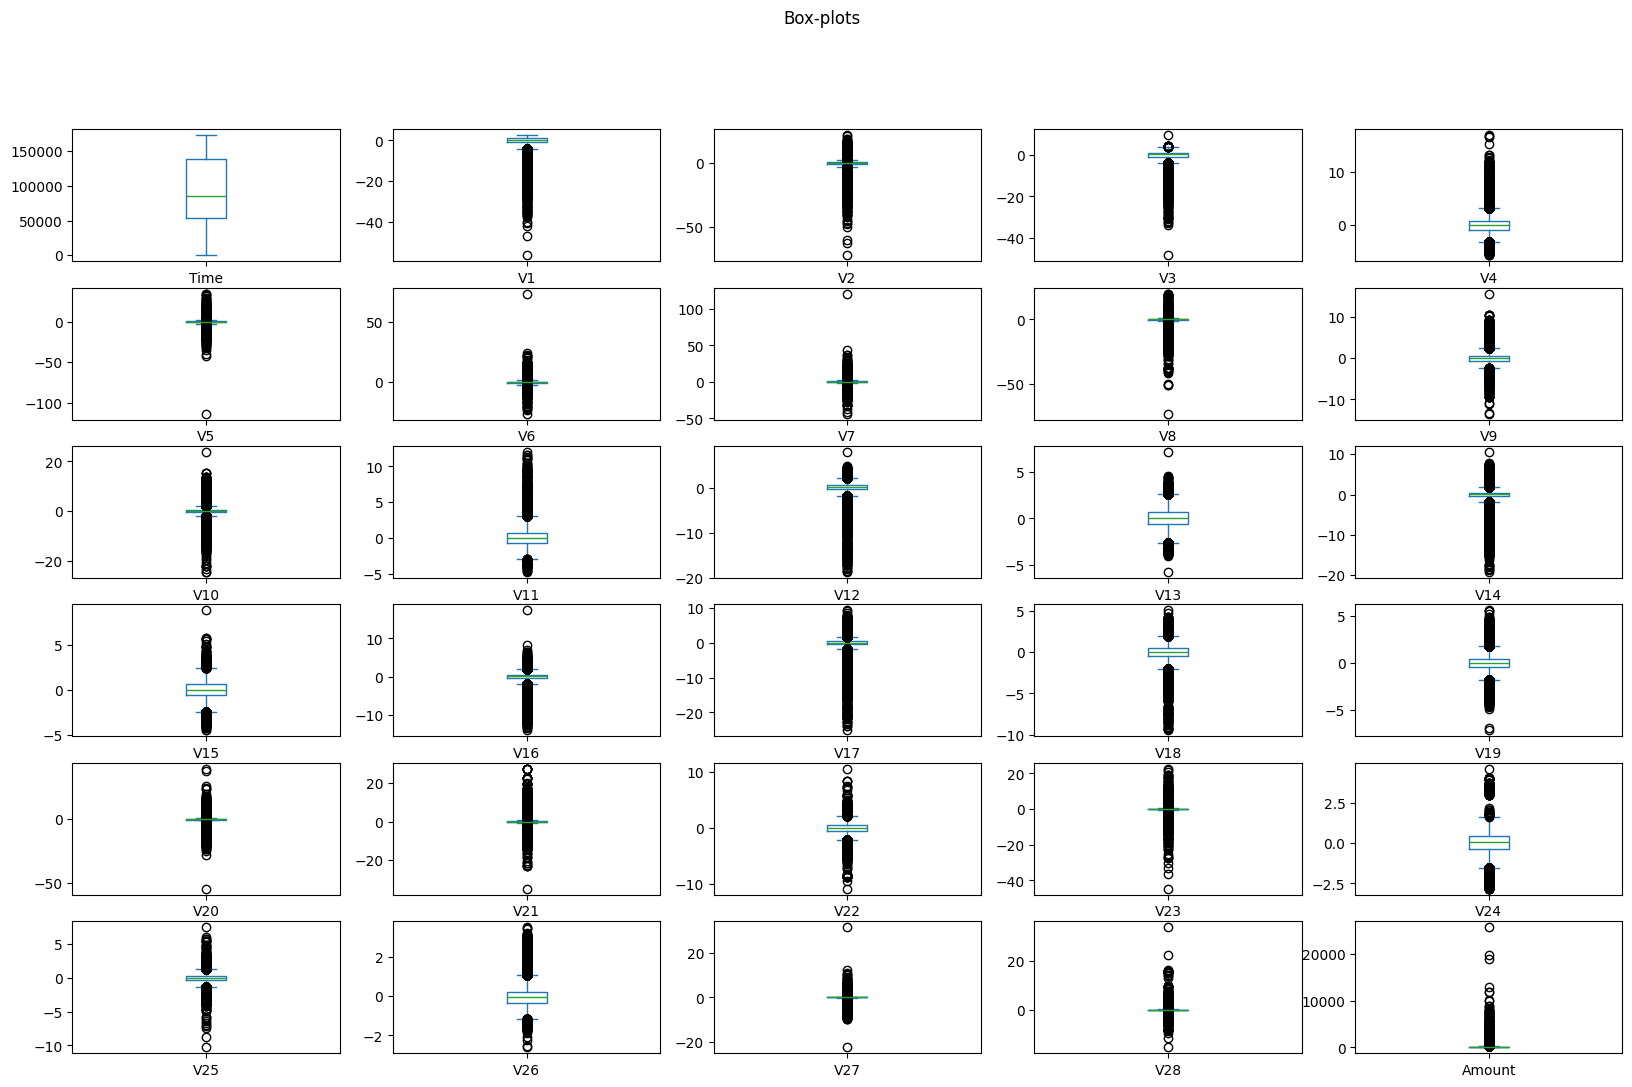

In [12]:
fig, axes = plt.subplots(6, 5, figsize=(20, 12))
fig.suptitle('Box-plots')

row=0
col=0

for ax, feature in enumerate(data):
    data[feature].plot.box(ax=axes[row, col])
    col+=1
    if col > 4:
        row+=1
        col=0

In [13]:
def outlier_iqr(data, col, threshold=1.5):
    IQR = data[col].quantile(0.75) - data[col].quantile(0.25)
    up_bound = data[col].quantile(0.75) + (IQR * threshold)
    low_bound = data[col].quantile(0.25) - (IQR * threshold)
    anomalies = pd.concat([data[col]>up_bound, data[col]<low_bound], axis=1).any(axis = 1)
    return anomalies, up_bound, low_bound

In [14]:
comparison_table, iqr_outliers = find_anomalies_threashold(data, outlier_iqr)
iqr_outliers_count, iqr_outliers_percent = anomalies_report(iqr_outliers)
comparison_table

Total number of outliers: 480
Percentage of outliers: 0.16853518347512525


,upper_bound,lower_bound,anomalies_count,anomalies_percentage
Amount,3.154460e+03,-3.071695e+03,253.0,0.088832
V28,5.721589e+00,-5.696269e+00,95.0,0.033356
V20,1.495782e+01,-1.503650e+01,72.0,0.025280
V23,1.345564e+01,-1.346985e+01,70.0,0.024578
V8,2.337430e+01,-2.325558e+01,50.0,0.017556
V27,7.052085e+00,-7.031879e+00,42.0,0.014747
V21,1.802158e+01,-1.806360e+01,32.0,0.011236
V2,6.110150e+01,-6.089632e+01,2.0,0.000702
V6,5.057357e+01,-5.094330e+01,1.0,0.000351
V7,4.892445e+01,-4.890809e+01,1.0,0.000351


In [15]:
class DistanceOutliers(BaseEstimator):
    """
    -----------
    Parameters:

    - metric: string, default - euclidean
        metric to use for distance calculation (see scipy.spatial.distance.cdist)

    - percentile: float in range [0, 100]
        hyperparameter which sets the threshold for anomalies
    """
    def __init__(self, metric='euclidean', percentile=90):
        self.metric = metric
        self.percentile = percentile

    def fit(self, X):
        self.centroid = np.mean(X, axis=0).values.reshape(-1, 1).T
        distances_train = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        self.threshold = np.percentile(distances_train, self.percentile)

    def predict(self, X):
        distances = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        predictions = (distances > self.threshold).astype(int)
        return predictions

In [16]:
euclidian_model = DistanceOutliers(metric='euclidean', percentile=100-anomalies_percent)
euclidian_model.fit(scaled_data)
euclidian_outliers = euclidian_model.predict(scaled_data)
euclidian_outliers_count, euclidian_outliers_percent = anomalies_report(euclidian_outliers)

Total number of outliers: 492
Percentage of outliers: 0.1727485630620034


In [17]:
scaled_data = pd.DataFrame(
    data=RobustScaler().fit_transform(data),
    columns=data.columns
)

citiblock_model = DistanceOutliers(metric='cityblock', percentile=100-anomalies_percent)
citiblock_model.fit(scaled_data)
cityblock_outliers = citiblock_model.predict(scaled_data)
cityblock_outliers_count, cityblock_outliers_percent = anomalies_report(cityblock_outliers)

Total number of outliers: 492
Percentage of outliers: 0.1727485630620034


In [18]:
# для начала считаем все наблюдения аномальными
# outlier_percentage = 1.

# берем маленький эпсилон и начинаем увеличивать
# eps = 0.01
# step = 0.05
# density_outlier = model = None
# while outlier_percentage > anomalies_percent / 100:
#     del(model)
#     del(density_outlier)
#     model = DBSCAN(eps=eps).fit(scaled_data)
#     density_outlier = np.array([1 if label == -1 else 0 for label in model.labels_])
#     # считаем текущий процент "шума"
#     outlier_percentage = sum(density_outlier==1) / len(density_outlier)
#     eps += step

# anomalies_report(density_outlier)

In [19]:
# model = DBSCAN(eps=1).fit(scaled_data)
# density_outlier = np.array([1 if label == -1 else 0 for label in model.labels_])
# density_outliers_count, density_outliers_percent = anomalies_report(density_outlier)

In [20]:
one_class_svm = OneClassSVM(nu=anomalies_percent / 100, gamma='auto')
one_class_svm.fit(scaled_data)
svm_outliers = one_class_svm.predict(scaled_data)
svm_outliers = np.array([1 if label == -1 else 0 for label in svm_outliers])
svm_outliers_count, svm_outliers_percent = anomalies_report(svm_outliers)

Total number of outliers: 2776
Percentage of outliers: 0.9746951444311411


In [21]:
isolation_forest = IsolationForest(n_estimators=300, contamination=anomalies_percent / 100, bootstrap=True)
isolation_forest.fit(scaled_data)

isolation_outliers = isolation_forest.predict(scaled_data)
isolation_outliers = np.array([1 if label == -1 else 0 for label in isolation_outliers])
isolation_outliers_count, isolation_outliers_percent = anomalies_report(isolation_outliers)

Total number of outliers: 492
Percentage of outliers: 0.1727485630620034


In [39]:
base_outliers = source_data['Class']

results = {
    "STD аномалии": (std_outliers_count, std_outliers_percent, std_outliers),
    "STD аномалии (трансформация к нормальному распределению)": (std_t_outliers_count, std_t_outliers_percent, std_t_outliers),
    "IQR аномалии": (iqr_outliers_count, iqr_outliers_percent, iqr_outliers),
    "Аномалии по евклидовому расстоянию": (euclidian_outliers_count, euclidian_outliers_percent, euclidian_outliers),
    "Аномалии по манхэттенскому расстоянию": (cityblock_outliers_count, cityblock_outliers_percent, cityblock_outliers),
    "SVM аномалии": (svm_outliers_count, svm_outliers_percent, svm_outliers),
    "Isolation Forest аномалии": (isolation_outliers_count, isolation_outliers_percent, isolation_outliers),
}

In [40]:
print(f"Базовый процент аномалий: {anomalies_percent:.2f}% ({anomalies})")

for method_name, item in results.items():
    count, percent, outliers = item
    correct_count = 0
    for i in range(len(base_outliers)):
        if base_outliers[i] ==  1 and base_outliers[i] == outliers[i]:
            correct_count += 1
    print(f"{method_name}: {percent:.2f}% ({count}). Аномалий определено правильно: {correct_count}")

Базовый процент аномалий: 0.17% (492)
STD аномалии: 0.15% (433). Аномалий определено правильно: 77
STD аномалии (трансформация к нормальному распределению): 0.15% (433). Аномалий определено правильно: 0
IQR аномалии: 0.17% (480). Аномалий определено правильно: 15
Аномалии по евклидовому расстоянию: 0.17% (492). Аномалий определено правильно: 18
Аномалии по манхэттенскому расстоянию: 0.17% (492). Аномалий определено правильно: 112
SVM аномалии: 0.97% (2776). Аномалий определено правильно: 148
Isolation Forest аномалии: 0.17% (492). Аномалий определено правильно: 120


STD аномалии:
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.18      0.16      0.17       492

    accuracy                           1.00    284807
   macro avg       0.59      0.58      0.58    284807
weighted avg       1.00      1.00      1.00    284807



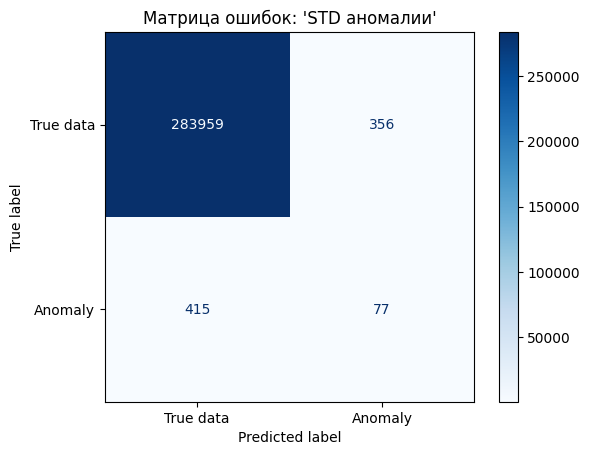

STD аномалии (трансформация к нормальному распределению):
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



/home/xr443/PycharmProjects/PythonEdu/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xr443/PycharmProjects/PythonEdu/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xr443/PycharmProjects/PythonEdu/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

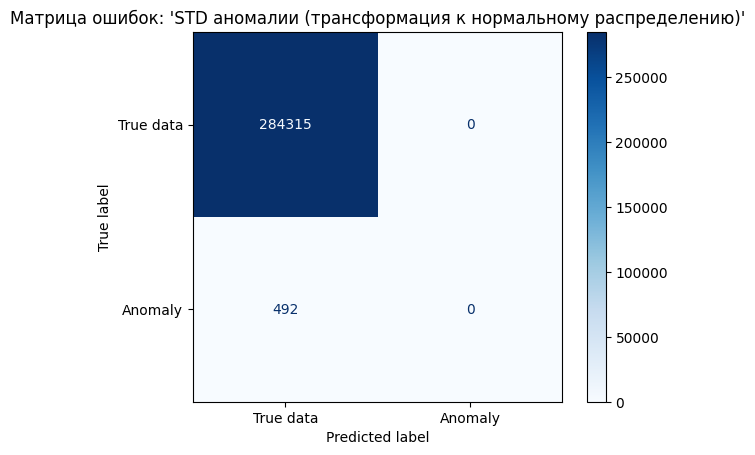

IQR аномалии:
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.03      0.03      0.03       492

    accuracy                           1.00    284807
   macro avg       0.51      0.51      0.51    284807
weighted avg       1.00      1.00      1.00    284807



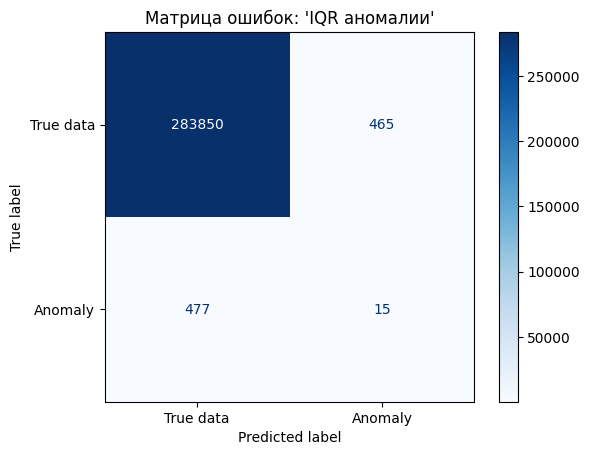

Аномалии по евклидовому расстоянию:
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.04      0.04      0.04       492

    accuracy                           1.00    284807
   macro avg       0.52      0.52      0.52    284807
weighted avg       1.00      1.00      1.00    284807



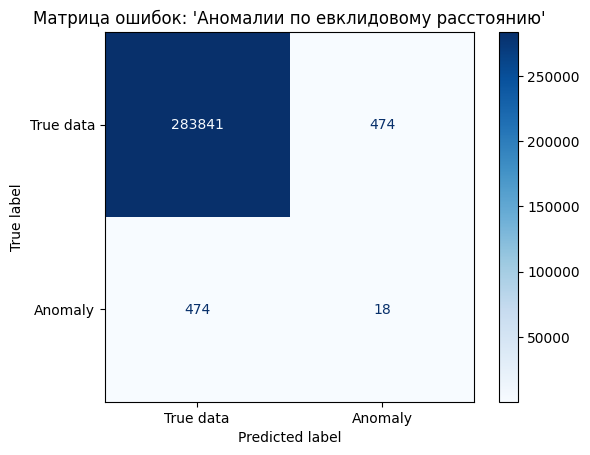

Аномалии по манхэттенскому расстоянию:
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.23      0.23      0.23       492

    accuracy                           1.00    284807
   macro avg       0.61      0.61      0.61    284807
weighted avg       1.00      1.00      1.00    284807



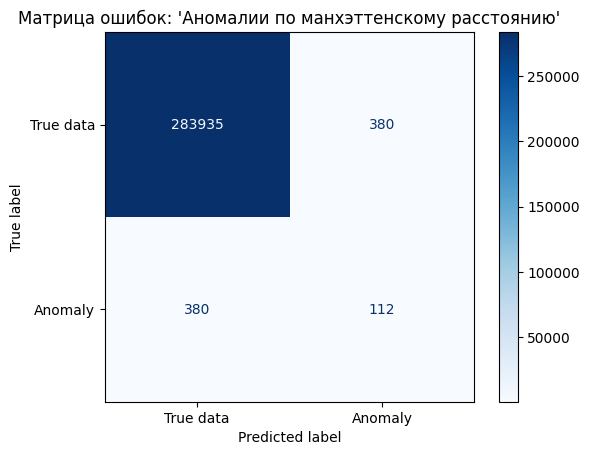

SVM аномалии:
              precision    recall  f1-score   support

   True data       1.00      0.99      0.99    284315
     Anomaly       0.05      0.30      0.09       492

    accuracy                           0.99    284807
   macro avg       0.53      0.65      0.54    284807
weighted avg       1.00      0.99      0.99    284807



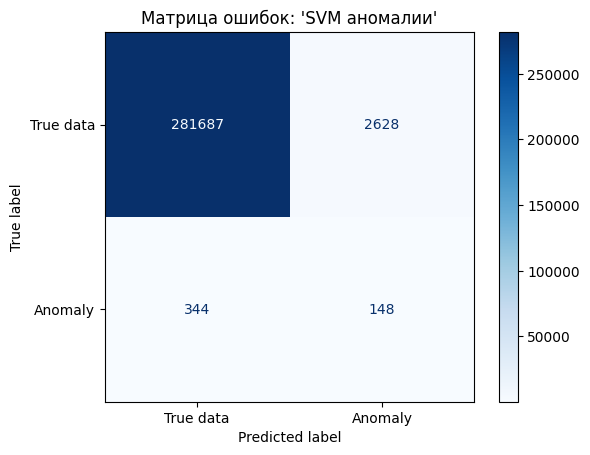

Isolation Forest аномалии:
              precision    recall  f1-score   support

   True data       1.00      1.00      1.00    284315
     Anomaly       0.24      0.24      0.24       492

    accuracy                           1.00    284807
   macro avg       0.62      0.62      0.62    284807
weighted avg       1.00      1.00      1.00    284807



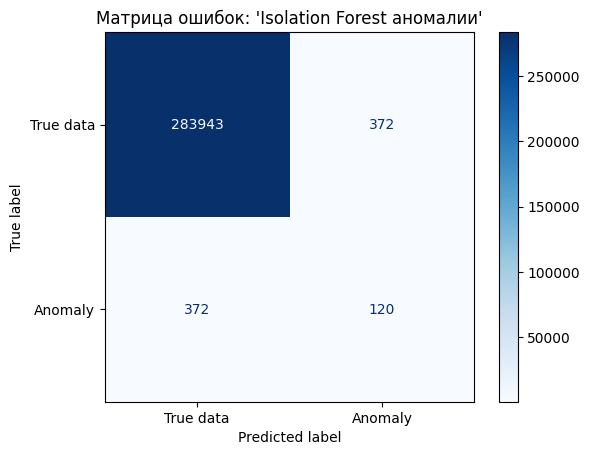

In [46]:
for method_name, item in results.items():
    count, percent, outliers = item
    cr = classification_report(base_outliers, outliers, labels=[0, 1], target_names=["True data", "Anomaly"])
    print(f"{method_name}:\n{cr}")
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(base_outliers, outliers, labels=[0, 1]), 
                                  display_labels=["True data", "Anomaly"])
    disp.plot(cmap='Blues')
    plt.title(f"Матрица ошибок: '{method_name}'")
    plt.show()